## 1. Standard Scaling
`Standard scaling` is a method of scaling the data such that the distribution of the data is centered around 0, with a standard deviation of 1. This is done by subtracting the mean of the data from each data point and then dividing by the standard deviation of the data. This is a very common method of scaling data, and is used in many machine learning algorithms.

The formula is as follows:

z = (x - μ) / σ

In [1]:
# import libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler


In [2]:
# make an example dataframe
data = {
    'feature1': [10, 20, 30, 40, 50],
    'feature2': [100, 200, 300, 400, 500]
}

df = pd.DataFrame(data)
df.head()

,feature1,feature2
0,10,100
1,20,200
2,30,300
3,40,400
4,50,500


In [4]:
# initialize the scaler
scalar = StandardScaler()

# fit and transform the data
scaled_data = scalar.fit_transform(df)

# convert the scaled data back to a dataframe
scaled_df = pd.DataFrame(scaled_data, columns=["age", "salary"])
scaled_df.head()

,age,salary
0,-1.414214,-1.414214
1,-0.707107,-0.707107
2,0.000000,0.000000
3,0.707107,0.707107
4,1.414214,1.414214


## Min-Max Scalar

In [5]:
scalar = MinMaxScaler()
scaled_data = scalar.fit_transform(df)
scaled_df = pd.DataFrame(scaled_data, columns=["age", "salary"])
scaled_df.head()

,age,salary
0,0.00,0.00
1,0.25,0.25
2,0.50,0.50
3,0.75,0.75
4,1.00,1.00


## Max Abc Scalar

In [6]:
scalar = MaxAbsScaler()
scaled_data = scalar.fit_transform(df)
scaled_df = pd.DataFrame(scaled_data, columns=["age", "salary"])
scaled_df.head()

,age,salary
0,0.2,0.2
1,0.4,0.4
2,0.6,0.6
3,0.8,0.8
4,1.0,1.0


In [7]:
from sklearn.preprocessing import RobustScaler
scalar = RobustScaler()
scaled_data = scalar.fit_transform(df)
scaled_df = pd.DataFrame(scaled_data, columns=["age", "salary"])
scaled_df.head()

,age,salary
0,-1.0,-1.0
1,-0.5,-0.5
2,0.0,0.0
3,0.5,0.5
4,1.0,1.0


## Transformation

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# generate a non-normal dataset
np.random.seed(0)  # for reproducibility
df = np.random.exponential(scale=2, size=1000)
df = pd.DataFrame(df, columns=['value'])
df.head()


,value
0,1.591749
1,2.511862
2,1.846446
3,1.574402
4,1.102097


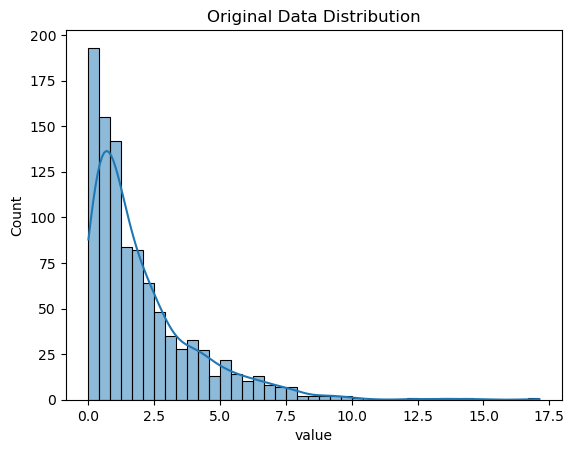

In [11]:
sns.histplot(df['value'], kde=True)
plt.title('Original Data Distribution')
plt.show()

In [16]:
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import QuantileTransformer

pt_normal = QuantileTransformer(output_distribution='normal')
pt_yeo_johnson = PowerTransformer(method='yeo-johnson')
pt_box_cox = PowerTransformer(method='box-cox')
# boxcox requires all positive data
df['BoxCox'] = pt_box_cox.fit_transform(df[['value']]+1)  # shift data to be positive
df['YeoJohnson'] = pt_yeo_johnson.fit_transform(df[['value']])
df['QuantileNormal'] = pt_normal.fit_transform(df[['value']])
df.head()



,value,BoxCox,YeoJohnson,QuantileNormal
0,1.591749,0.179335,0.179335,0.162552
1,2.511862,0.677330,0.677331,0.587964
2,1.846446,0.339698,0.339698,0.286135
3,1.574402,0.167607,0.167607,0.157469
4,1.102097,-0.202107,-0.202107,-0.154930


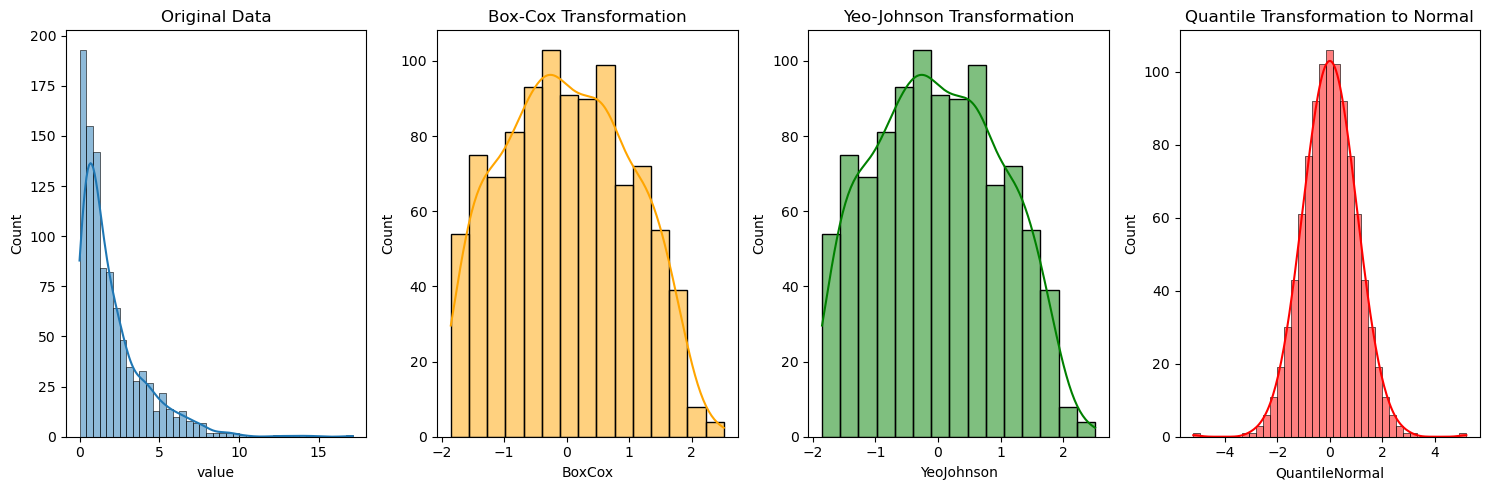

In [17]:
# create histograms to compare distributions
plt.figure(figsize=(15, 5))
plt.subplot(1, 4, 1)
sns.histplot(df['value'], kde=True)
plt.title('Original Data')
plt.subplot(1, 4, 2)
sns.histplot(df['BoxCox'], kde=True, color='orange')
plt.title('Box-Cox Transformation')
plt.subplot(1, 4, 3)
sns.histplot(df['YeoJohnson'], kde=True, color='green')
plt.title('Yeo-Johnson Transformation')
plt.subplot(1, 4, 4)
sns.histplot(df['QuantileNormal'], kde=True, color='red')
plt.title('Quantile Transformation to Normal')
plt.tight_layout()
plt.show()